In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("2024-yili-arama-kurtarma.xlsx")

In [4]:
data.head()

,TARIH,KURTARMA_TURU,CIKIS_SAATI,VARIS_SURESI,MAHALLE,ILCE,ERKEK_VEFAT,KADIN_VEFAT,ITFAIYECI_VEFAT,ERKEK_YARALI,KADIN_YARALI,ITFAIYECI_YARALI,BUYUK_BAS_VEFAT,KUCUK_BAS_VEFAT,KUMES_HAYVANI_VEFAT,EVCIL_HAYVAN_VEFAT,DIGER,ADRES_BOLGESI
0,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:41,00:04,GÜNEY,KONAK,0,0,0,0,0,0,0,0,0,0,0,KENT MERKEZİ
1,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:50,NaN,GÜMÜŞPALA,BAYRAKLI,0,0,0,1,0,0,0,0,0,0,0,KENT MERKEZİ
2,1.01.2024,TRAFİK KAZASI,01:26,00:04,KURUÇEŞME,BUCA,0,0,0,0,0,0,0,0,0,0,0,KENT MERKEZİ
3,1.01.2024,112 ACİL SAĞLIK/AMBULANS,01:58,00:07,BOSTANLI,KARŞIYAKA,0,0,0,0,0,0,0,0,0,0,0,KENT MERKEZİ
4,1.01.2024,YÜZÜK KESME,02:42,00:03,KAZIMDİRİK,BORNOVA,0,0,0,1,0,0,0,0,0,0,0,KENT MERKEZİ


### analizde hayvanların vefatı, adres bölgesi gibi kullanmayacağımız verileri çıkartacağız

In [5]:
data = data[["TARIH", "KURTARMA_TURU", "CIKIS_SAATI", "VARIS_SURESI", "MAHALLE", "ILCE", "ERKEK_VEFAT", "KADIN_VEFAT"]].copy()

In [6]:
data.head()

,TARIH,KURTARMA_TURU,CIKIS_SAATI,VARIS_SURESI,MAHALLE,ILCE,ERKEK_VEFAT,KADIN_VEFAT
0,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:41,00:04,GÜNEY,KONAK,0,0
1,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:50,NaN,GÜMÜŞPALA,BAYRAKLI,0,0
2,1.01.2024,TRAFİK KAZASI,01:26,00:04,KURUÇEŞME,BUCA,0,0
3,1.01.2024,112 ACİL SAĞLIK/AMBULANS,01:58,00:07,BOSTANLI,KARŞIYAKA,0,0
4,1.01.2024,YÜZÜK KESME,02:42,00:03,KAZIMDİRİK,BORNOVA,0,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12828 entries, 0 to 12827
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TARIH          12828 non-null  object
 1   KURTARMA_TURU  12828 non-null  object
 2   CIKIS_SAATI    12828 non-null  object
 3   VARIS_SURESI   12760 non-null  object
 4   MAHALLE        12803 non-null  object
 5   ILCE           12828 non-null  object
 6   ERKEK_VEFAT    12828 non-null  int64 
 7   KADIN_VEFAT    12828 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 801.9+ KB


### eksik veriler var.

In [8]:
data.isnull().sum()

TARIH             0
KURTARMA_TURU     0
CIKIS_SAATI       0
VARIS_SURESI     68
MAHALLE          25
ILCE              0
ERKEK_VEFAT       0
KADIN_VEFAT       0
dtype: int64

### varış süresinin girilmediği sadece 68 tane veri olduğundan bunları direkt siliyoruz. Aynı şekilde mahalle sütununda da uyguluyoruz.

In [9]:
data.dropna(subset=["VARIS_SURESI", "MAHALLE"], inplace=True)
data.isnull().sum()

TARIH            0
KURTARMA_TURU    0
CIKIS_SAATI      0
VARIS_SURESI     0
MAHALLE          0
ILCE             0
ERKEK_VEFAT      0
KADIN_VEFAT      0
dtype: int64

In [10]:
def sureyi_hesapla(x):
    # Eğer veri string değilse veya boşsa (NaN) doğrudan 0 veya None döndür
    if not isinstance(x, str) or ":" not in str(x):
        return 0 
    
    parcalar = x.split(':')
    # HH:MM formatını dakikaya çeviriyoruz
    return int(parcalar[0]) * 60 + int(parcalar[1])

## Varış Süresi sütununu sayısal olarak dakikaya çevirip 0 dakika olanları temizledik

In [11]:
data["TOPLAM_VARIS_SURESI"] = data["VARIS_SURESI"].apply(sureyi_hesapla)
data = data[data['TOPLAM_VARIS_SURESI'] > 0]

In [12]:
data.head()

,TARIH,KURTARMA_TURU,CIKIS_SAATI,VARIS_SURESI,MAHALLE,ILCE,ERKEK_VEFAT,KADIN_VEFAT,TOPLAM_VARIS_SURESI
0,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:41,00:04,GÜNEY,KONAK,0,0,4
2,1.01.2024,TRAFİK KAZASI,01:26,00:04,KURUÇEŞME,BUCA,0,0,4
3,1.01.2024,112 ACİL SAĞLIK/AMBULANS,01:58,00:07,BOSTANLI,KARŞIYAKA,0,0,7
4,1.01.2024,YÜZÜK KESME,02:42,00:03,KAZIMDİRİK,BORNOVA,0,0,3
5,1.01.2024,HAYVAN (KÖPEK) KURTARMA,09:14,00:05,HÜRRİYET,GAZİEMİR,0,0,5


In [13]:
data.describe()

,ERKEK_VEFAT,KADIN_VEFAT,TOPLAM_VARIS_SURESI
count,12734.000000,12734.000000,12734.000000
mean,0.016962,0.006282,6.578373
std,0.135081,0.088398,14.258079
min,0.000000,0.000000,1.000000
25%,0.000000,0.000000,3.000000
50%,0.000000,0.000000,5.000000
75%,0.000000,0.000000,6.000000
max,3.000000,3.000000,981.000000


In [17]:
ilce_ortalama_varis = data.groupby('ILCE')['TOPLAM_VARIS_SURESI'].mean().sort_values()
ilce_ortalama_varis

ILCE
KINIK            4.162162
ALİAĞA           5.036364
FOÇA             5.127119
ÇEŞME            5.492462
BAYRAKLI         5.574794
BORNOVA          5.729522
NARLIDERE        5.785714
MENEMEN          5.831754
KARŞIYAKA        5.854512
ÇİĞLİ            5.885135
TORBALI          5.902669
BERGAMA          5.922794
KONAK            6.008387
TİRE             6.062147
GAZİEMİR         6.087719
BALÇOVA          6.113695
SELÇUK           6.375000
SEFERİHİSAR      6.381643
KARABURUN        6.725000
GÜZELBAHÇE       6.729508
ÖDEMİŞ           7.000000
DİKİLİ           7.265896
BUCA             7.508516
KARABAĞLAR       7.610269
MENDERES         8.049587
KEMALPAŞA        8.075758
URLA             8.375000
BEYDAĞ           8.500000
BAYINDIR         8.969697
KİRAZ            9.210526
İL DIŞI        534.750000
Name: TOPLAM_VARIS_SURESI, dtype: float64

### İL DIŞI        534.750000
### bu satırı kaldırırsak verilerimiz daha tutarlı olacaktır ki zaten bizim ilgilendiğimiz izmir il sınırları içerisi.

In [19]:
data = data[data['ILCE'] != 'İL DIŞI']

In [20]:
ilce_ortalama_varis = data.groupby('ILCE')['TOPLAM_VARIS_SURESI'].mean().sort_values()
ilce_ortalama_varis

ILCE
KINIK          4.162162
ALİAĞA         5.036364
FOÇA           5.127119
ÇEŞME          5.492462
BAYRAKLI       5.574794
BORNOVA        5.729522
NARLIDERE      5.785714
MENEMEN        5.831754
KARŞIYAKA      5.854512
ÇİĞLİ          5.885135
TORBALI        5.902669
BERGAMA        5.922794
KONAK          6.008387
TİRE           6.062147
GAZİEMİR       6.087719
BALÇOVA        6.113695
SELÇUK         6.375000
SEFERİHİSAR    6.381643
KARABURUN      6.725000
GÜZELBAHÇE     6.729508
ÖDEMİŞ         7.000000
DİKİLİ         7.265896
BUCA           7.508516
KARABAĞLAR     7.610269
MENDERES       8.049587
KEMALPAŞA      8.075758
URLA           8.375000
BEYDAĞ         8.500000
BAYINDIR       8.969697
KİRAZ          9.210526
Name: TOPLAM_VARIS_SURESI, dtype: float64

In [21]:
data.describe()

,ERKEK_VEFAT,KADIN_VEFAT,TOPLAM_VARIS_SURESI
count,12730.000000,12730.000000,12730.000000
mean,0.016968,0.006284,6.412412
std,0.135101,0.088411,9.650881
min,0.000000,0.000000,1.000000
25%,0.000000,0.000000,3.000000
50%,0.000000,0.000000,5.000000
75%,0.000000,0.000000,6.000000
max,3.000000,3.000000,628.000000


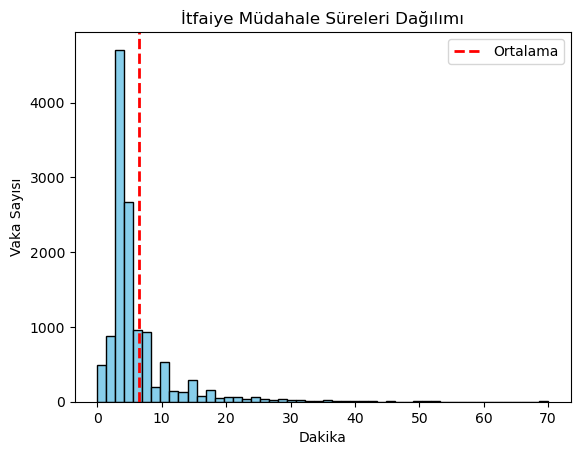

In [23]:
plt.hist(data['TOPLAM_VARIS_SURESI'], bins=50, color='skyblue', edgecolor='black', range=(0,70))
plt.axvline(data['TOPLAM_VARIS_SURESI'].mean(), color='red', linestyle='dashed', linewidth=2, label='Ortalama')

plt.title('İtfaiye Müdahale Süreleri Dağılımı')
plt.xlabel('Dakika')
plt.ylabel('Vaka Sayısı')
plt.legend()
plt.show()

In [32]:
kurtarma_analizi = data.groupby('KURTARMA_TURU')['TOPLAM_VARIS_SURESI'].mean().sort_values()
kurtarma_analizi

KURTARMA_TURU
KBRN KURTARMA/EMNİYET                                    3.000000
ASANSÖRDEN KURTARMA                                      4.299270
EV KAZASI                                                4.400000
KAPI AÇMA (ACİL DURUM)                                   4.438819
HAYVAN (KEDİ) KURTARMA                                   4.672712
BİNADA MAHSUR KALMA                                      4.711207
İNTİHAR GİRİŞİMİ                                         4.915301
AĞAÇ DEVRİLMESİ                                          4.961111
HAYVAN (KUŞ VB.) KURTARMA                                4.991364
HEYELAN (TOPRAK KAYMASI/İSTİNAT DUVARI YIKILMASI VB)     5.000000
SIKIŞMA                                                  5.140351
CESET ÇIKARMA                                            5.214286
ARAÇTA MAHSUR KALMA                                      5.603448
ÇATI/TABELA/PANO VB. UÇMASI                              5.692308
DÜŞME (DERE/ÇUKUR VB)                                    5.816

In [33]:
kurtarma_analizi.describe()

count    30.000000
mean      7.174158
std       4.043243
min       3.000000
25%       4.968674
50%       5.859713
75%       6.960717
max      19.846154
Name: TOPLAM_VARIS_SURESI, dtype: float64

Kurtarma Türlerine Göre Ortalama Varış Süreleri (Dakika):
KURTARMA_TURU
KBRN KURTARMA/EMNİYET                                    3.000000
ASANSÖRDEN KURTARMA                                      4.299270
EV KAZASI                                                4.400000
KAPI AÇMA (ACİL DURUM)                                   4.438819
HAYVAN (KEDİ) KURTARMA                                   4.672712
BİNADA MAHSUR KALMA                                      4.711207
İNTİHAR GİRİŞİMİ                                         4.915301
AĞAÇ DEVRİLMESİ                                          4.961111
HAYVAN (KUŞ VB.) KURTARMA                                4.991364
HEYELAN (TOPRAK KAYMASI/İSTİNAT DUVARI YIKILMASI VB)     5.000000
SIKIŞMA                                                  5.140351
CESET ÇIKARMA                                            5.214286
ARAÇTA MAHSUR KALMA                                      5.603448
ÇATI/TABELA/PANO VB. UÇMASI                              5.692308
DÜŞM

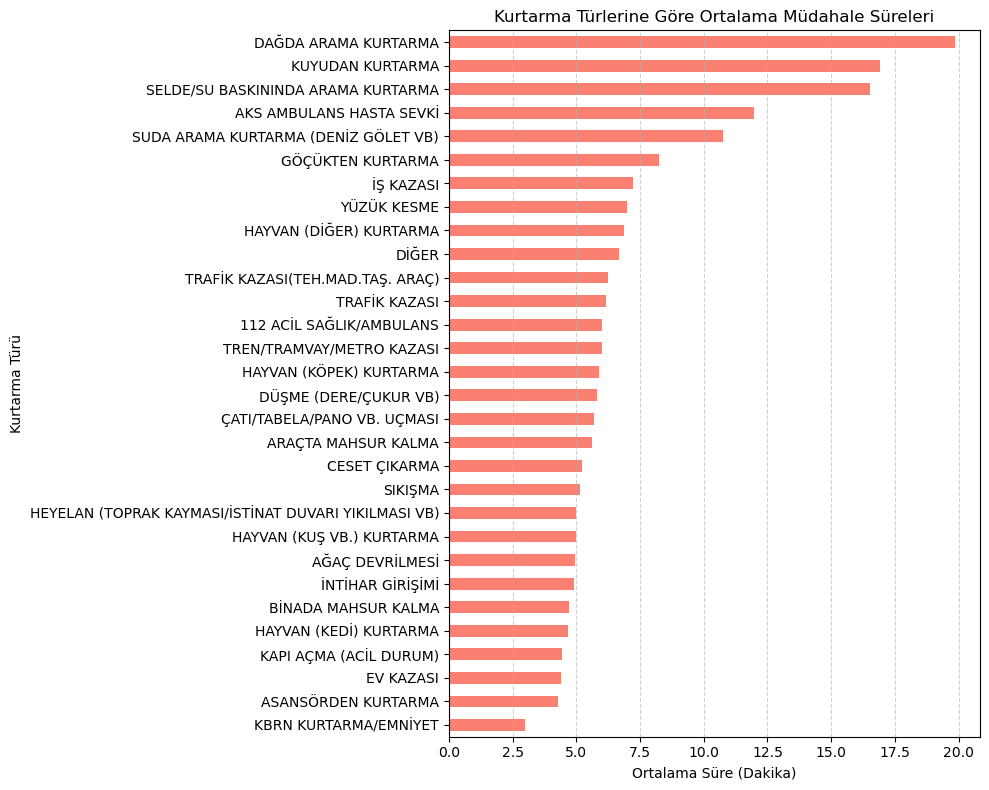

In [35]:
# Sonuçları listele
print("Kurtarma Türlerine Göre Ortalama Varış Süreleri (Dakika):")
print(kurtarma_analizi)

kurtarma_analizi.plot(kind='barh', color='salmon', figsize=(10, 8))
plt.title('Kurtarma Türlerine Göre Ortalama Müdahale Süreleri')
plt.xlabel('Ortalama Süre (Dakika)')
plt.ylabel('Kurtarma Türü')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('kurtarma_turu_analizi.png')

In [27]:
def ilce_veri_ayikla(ilce_adi):
    data_ilce = data[data['ILCE'] == ilce_adi]

    print(f"{ilce_adi} vaka dagilimi:")
    print(data_ilce["KURTARMA_TURU"].value_counts())

In [36]:
ilce_veri_ayikla("BUCA")

BUCA vaka dagilimi:
KURTARMA_TURU
AKS AMBULANS HASTA SEVKİ                                392
HAYVAN (KEDİ) KURTARMA                                  365
KAPI AÇMA (ACİL DURUM)                                  108
TRAFİK KAZASI                                            73
HAYVAN (KUŞ VB.) KURTARMA                                53
ASANSÖRDEN KURTARMA                                      53
İNTİHAR GİRİŞİMİ                                         39
HAYVAN (DİĞER) KURTARMA                                  30
HAYVAN (KÖPEK) KURTARMA                                  21
BİNADA MAHSUR KALMA                                      16
AĞAÇ DEVRİLMESİ                                          15
DİĞER                                                    14
112 ACİL SAĞLIK/AMBULANS                                 11
YÜZÜK KESME                                              11
ÇATI/TABELA/PANO VB. UÇMASI                               9
ARAÇTA MAHSUR KALMA                                       8
DÜŞME 

In [39]:
kurtarma_sayilari = data['KURTARMA_TURU'].value_counts()
kurtarma_sayilari

KURTARMA_TURU
HAYVAN (KEDİ) KURTARMA                                  3474
AKS AMBULANS HASTA SEVKİ                                2113
112 ACİL SAĞLIK/AMBULANS                                1415
TRAFİK KAZASI                                           1118
KAPI AÇMA (ACİL DURUM)                                   948
ASANSÖRDEN KURTARMA                                      685
HAYVAN (KUŞ VB.) KURTARMA                                579
HAYVAN (DİĞER) KURTARMA                                  485
İNTİHAR GİRİŞİMİ                                         366
HAYVAN (KÖPEK) KURTARMA                                  300
BİNADA MAHSUR KALMA                                      232
DİĞER                                                    189
AĞAÇ DEVRİLMESİ                                          180
YÜZÜK KESME                                              144
ÇATI/TABELA/PANO VB. UÇMASI                              143
DÜŞME (DERE/ÇUKUR VB)                                     87
ARAÇTA MAH

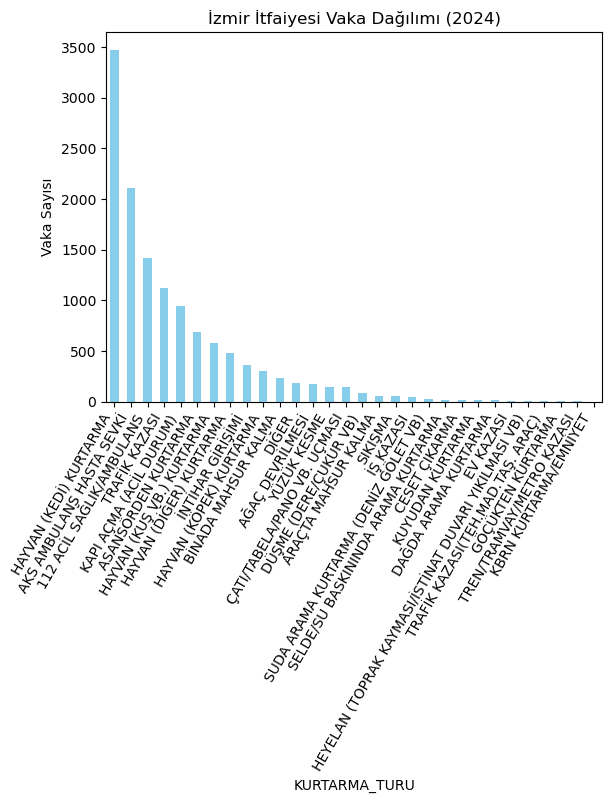

In [47]:
# Toplam adetleri sütun grafiğiyle göster
kurtarma_sayilari.plot(kind='bar', color='skyblue')
plt.title('İzmir İtfaiyesi Vaka Dağılımı (2024)')
plt.ylabel('Vaka Sayısı')
plt.xticks(rotation=60, ha='right')
plt.show()

### -------------------------------------------------------------------------------------------

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Kategorik verileri sayısallaştırma
le_ilce = LabelEncoder()
le_tur = LabelEncoder()

data['ILCE_KOD'] = le_ilce.fit_transform(data['ILCE'])
data['TUR_KOD'] = le_tur.fit_transform(data['KURTARMA_TURU'])

# Tahmin edilecek (y) ve tahmin için kullanılacak (X) sütunları seçme
X = data[['ILCE_KOD', 'TUR_KOD']]
y = data['TOPLAM_VARIS_SURESI']

In [49]:
# Veriyi %80 eğitim, %20 test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur ve eğit
model = DecisionTreeRegressor(max_depth=5) # Ağacın çok karmaşık olup ezberlememesi için derinliği sınırladık
model.fit(X_train, y_train)

# Tahmin yapma
tahminler = model.predict(X_test)

In [50]:
hata = mean_absolute_error(y_test, tahminler)
print(f"Modelin Ortalama Yanılma Payı: {hata:.2f} dakika")

Modelin Ortalama Yanılma Payı: 3.09 dakika


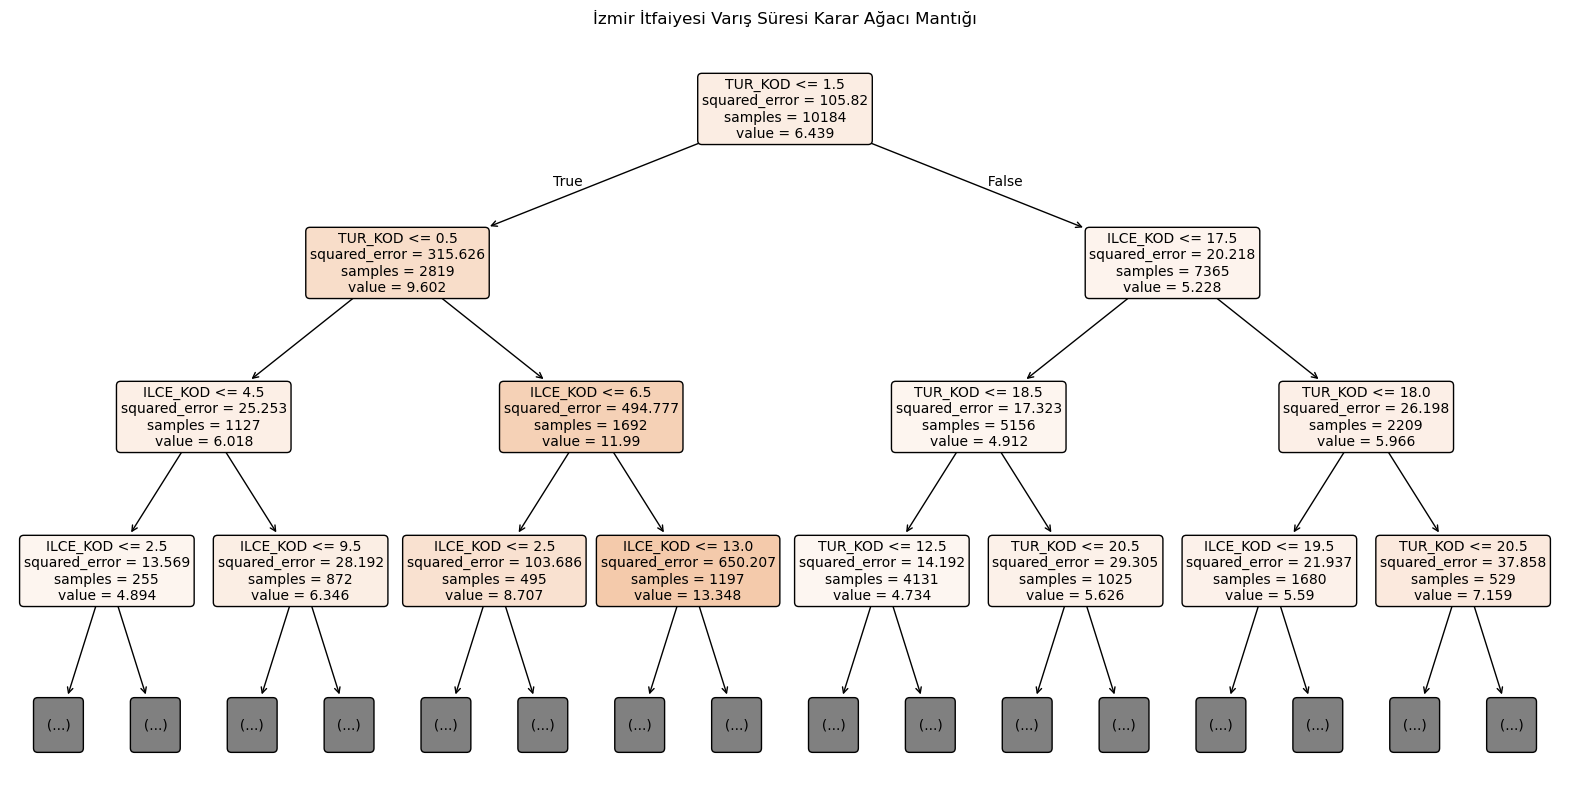

In [51]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Grafik boyutunu ayarlayalım
plt.figure(figsize=(20, 10))

# Ağacı çizdirelim
plot_tree(model, 
          feature_names=['ILCE_KOD', 'TUR_KOD'], 
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) # Okunabilir olması için derinliği 3 ile sınırladık

plt.title("İzmir İtfaiyesi Varış Süresi Karar Ağacı Mantığı")
plt.show()

In [52]:
importances = pd.Series(model.feature_importances_, index=['İlçe', 'Kurtarma Türü'])
print("Değişkenlerin Tahmin Gücü:")
print(importances)

Değişkenlerin Tahmin Gücü:
İlçe             0.262221
Kurtarma Türü    0.737779
dtype: float64


In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Modeli oluşturma (100 tane ağaç kullanacak şekilde ayarlandı)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Modeli eğitme
rf_model.fit(X_train, y_train)

# Tahmin yapma
rf_tahminler = rf_model.predict(X_test)

# Yeni hata payını (MAE) hesaplama
yeni_hata = mean_absolute_error(y_test, rf_tahminler)

print(f"Eski Hata Payı (Karar Ağacı): 3.09 dakika")
print(f"Yeni Hata Payı (Random Forest): {yeni_hata:.2f} dakika")

Eski Hata Payı (Karar Ağacı): 3.09 dakika
Yeni Hata Payı (Random Forest): 3.03 dakika


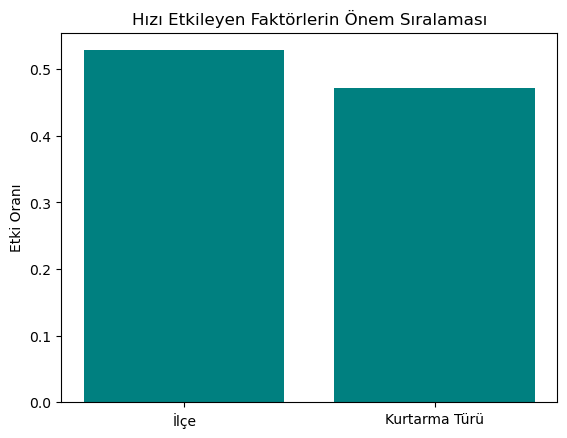

In [54]:
# Önem derecelerini alma
importances = rf_model.feature_importances_
feature_names = ['İlçe', 'Kurtarma Türü']
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False)

# Grafik çizimi
plt.bar(feature_importance_df['Özellik'], feature_importance_df['Önem'], color='teal')
plt.title('Hızı Etkileyen Faktörlerin Önem Sıralaması')
plt.ylabel('Etki Oranı')
plt.show()

In [55]:
# 1. İlçeye ve Kurtarma Türüne göre gruplayıp count (sayı) ve mean (ortalama) alalım
detayli_ozet = data.groupby(['ILCE', 'KURTARMA_TURU'])['TOPLAM_VARIS_SURESI'].agg(['count', 'mean'])

# 2. Sütun isimlerini daha anlaşılır yapalım
detayli_ozet.columns = ['Vaka Sayısı', 'Ortalama Varış Süresi (dk)']

# 3. Tüm satırları görebilmek için Pandas görüntüleme sınırını kaldıralım
pd.set_option('display.max_rows', None)

# Sonucu yazdıralım
print(detayli_ozet)

# İstersen bu tabloyu bir Excel dosyası olarak kaydedip daha rahat inceleyebilirsin
# detayli_ozet.to_excel("izmir_itfaiye_detayli_analiz.xlsx")

                                                                Vaka Sayısı  \
ILCE        KURTARMA_TURU                                                     
ALİAĞA      112 ACİL SAĞLIK/AMBULANS                                     27   
            AKS AMBULANS HASTA SEVKİ                                      4   
            ARAÇTA MAHSUR KALMA                                           1   
            ASANSÖRDEN KURTARMA                                          11   
            AĞAÇ DEVRİLMESİ                                               3   
            BİNADA MAHSUR KALMA                                          11   
            DÜŞME (DERE/ÇUKUR VB)                                         4   
            DİĞER                                                         7   
            EV KAZASI                                                     2   
            HAYVAN (DİĞER) KURTARMA                                      19   
            HAYVAN (KEDİ) KURTARMA                  

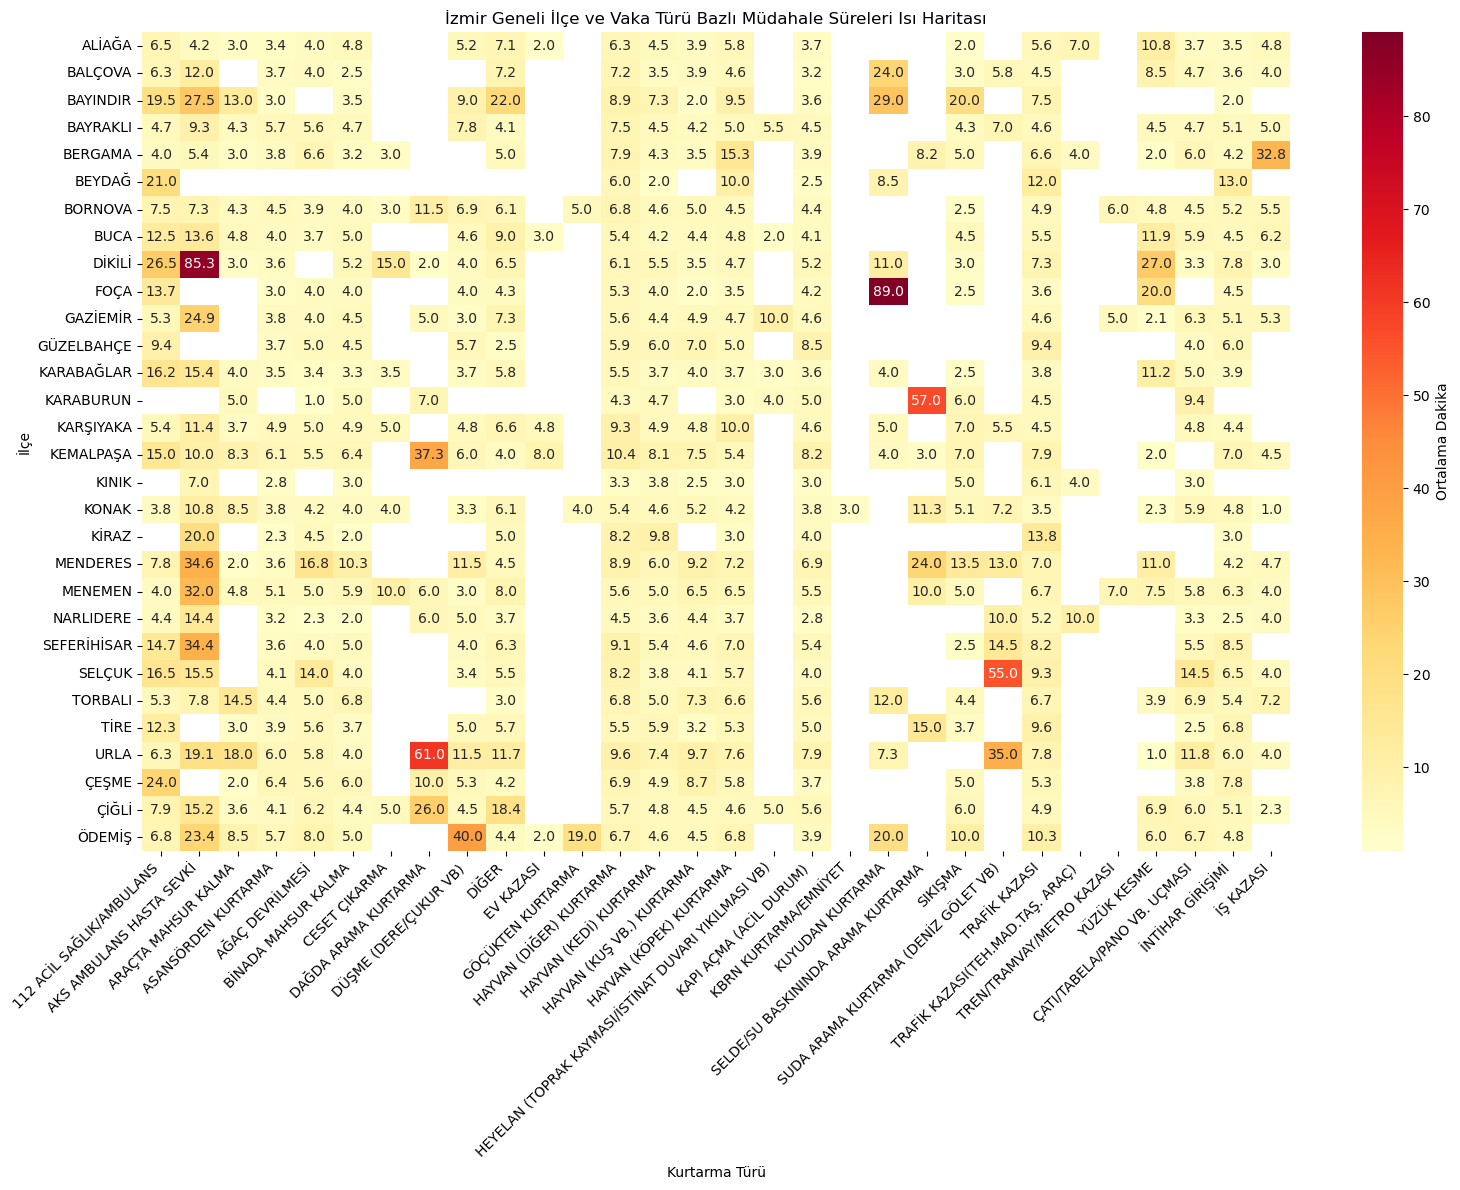

In [58]:
# 1. Veriyi pivot tablo haline getirelim (Satırlar: İlçe, Sütunlar: Kurtarma Türü, Değerler: Ortalama Süre)
pivot_data = data.pivot_table(index='ILCE', 
                          columns='KURTARMA_TURU', 
                          values='TOPLAM_VARIS_SURESI', 
                          aggfunc='mean')

# 2. Isı haritasını (Heatmap) çizdirelim
plt.figure(figsize=(16, 12))
sns.heatmap(pivot_data, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Ortalama Dakika'})

plt.title('İzmir Geneli İlçe ve Vaka Türü Bazlı Müdahale Süreleri Isı Haritası')
plt.xlabel('Kurtarma Türü')
plt.ylabel('İlçe')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('itfaiye_isi_haritasi.png')
plt.show()

In [61]:
dikili_vakalari = data[data['ILCE'] == 'DİKİLİ']
dikili_vakalari

,TARIH,KURTARMA_TURU,CIKIS_SAATI,VARIS_SURESI,MAHALLE,ILCE,ERKEK_VEFAT,KADIN_VEFAT,TOPLAM_VARIS_SURESI,ILCE_KOD,TUR_KOD
43,2.01.2024,HAYVAN (KEDİ) KURTARMA,15:23,00:04,SALİMBEY,DİKİLİ,0,0,4,8,13
221,8.01.2024,ÇATI/TABELA/PANO VB. UÇMASI,12:32,00:05,İSMETPAŞA,DİKİLİ,0,0,5,8,27
226,8.01.2024,HAYVAN (KEDİ) KURTARMA,16:15,00:07,CUMHURİYET,DİKİLİ,0,0,7,8,13
265,10.01.2024,ASANSÖRDEN KURTARMA,16:48,00:04,GAZİPAŞA,DİKİLİ,0,0,4,8,3
337,14.01.2024,ASANSÖRDEN KURTARMA,11:02,00:05,SALİMBEY,DİKİLİ,0,0,5,8,3
386,15.01.2024,ASANSÖRDEN KURTARMA,23:53,00:03,GAZİPAŞA,DİKİLİ,0,0,3,8,3
490,20.01.2024,TRAFİK KAZASI,01:10,00:06,CUMHURİYET,DİKİLİ,0,0,6,8,23
497,20.01.2024,HAYVAN (KEDİ) KURTARMA,15:11,00:03,İSMETPAŞA,DİKİLİ,0,0,3,8,13
503,20.01.2024,TRAFİK KAZASI,17:51,00:14,BAHÇELİ,DİKİLİ,0,0,14,8,23
522,21.01.2024,DİĞER,16:12,00:03,ÇANDARLI,DİKİLİ,0,0,3,8,9
